In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [15]:
RANDOM_STATE = 42
df = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")

feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)
#X_max = X_max.T
#print(X_max[0])

Number of features: 1230
X.shape = (8317, 1230)


In [17]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (8317, 1230)


In [20]:
for i in range(20):
    print(X_norm[i])

[0.02621911 0.02439404 0.05667386 ... 0.25090988 0.21132046 0.01074584]
[0.04997572 0.13503005 0.13761553 ... 0.10334961 0.11584253 0.02644753]
[0.04387209 0.07486556 0.16575211 ... 0.19227953 0.16299486 0.0052147 ]
[0.07185141 0.12019617 0.11578322 ... 0.30498779 0.28540765 0.00870002]
[0.00283708 0.00445062 0.0073809  ... 0.08683488 0.06920187 0.01883452]
[0.01291393 0.00643975 0.02099918 ... 0.32356721 0.19402822 0.03976041]
[0.0427654  0.03822541 0.01663593 ... 0.25481202 0.05745671 0.00461502]
[0.03235222 0.04183438 0.04028838 ... 0.19925372 0.03766843 0.02801769]
[0.02477947 0.04226651 0.0414371  ... 0.08007123 0.03618139 0.04566044]
[0.05129751 0.05569134 0.05257218 ... 0.30095454 0.28826972 0.04203552]
[0.09383301 0.20215955 0.20169575 ... 0.20477694 0.19189507 0.01575739]
[0.03473125 0.05662564 0.0508924  ... 0.21582469 0.26813931 0.03085778]
[0.02659734 0.01332395 0.04290889 ... 0.15323156 0.2064653  0.01501798]
[0.04252057 0.04466886 0.07320033 ... 0.25626904 0.13213435 0.01

In [98]:
PCA_COMPONENTS = 30

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=50,early_exaggeration=400,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='manhattan')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 30
Explained variance: 0.5321


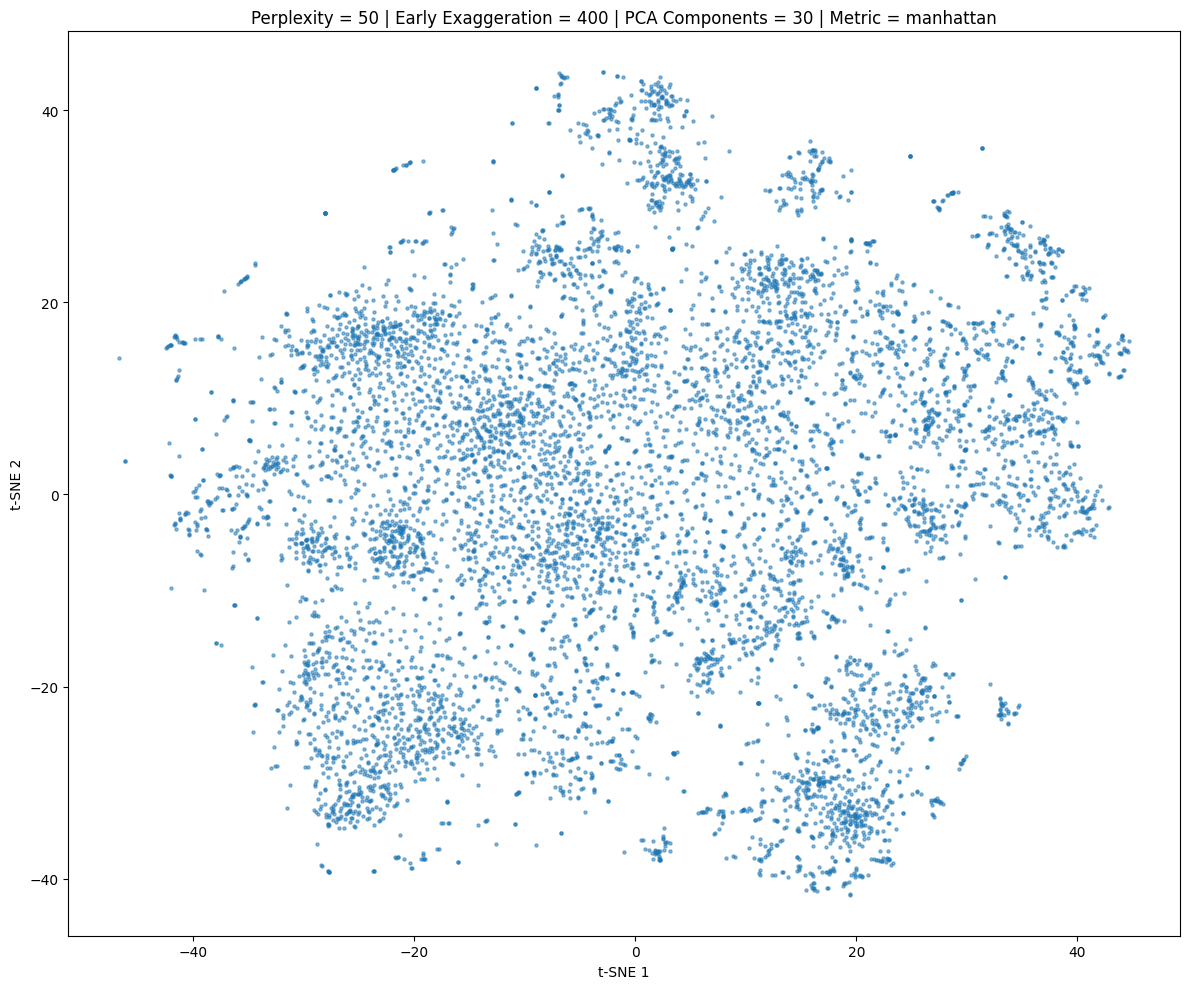

In [99]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Perplexity = 50 | Early Exaggeration = 400 | PCA Components = {PCA_COMPONENTS} | Metric = manhattan")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [100]:
def plot_masks(df,X_tsne,column,values,figure_title,ncols=3):
    nplots = len(values)
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(nrows,ncols,figsize=(6 * ncols, 5 * nrows),squeeze=False)
    axes = axes.flatten()
    for ax, value in zip(axes, values):
        mask = df[column] == value
        ax.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.10)
        ax.scatter(X_tsne[mask, 0],X_tsne[mask, 1],s=7,alpha=0.75)

        ax.set_title(f"{value}\n N = {mask.sum()}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for ax in axes[nplots:]:
        ax.remove()

    fig.suptitle(figure_title,fontsize=16)
    plt.tight_layout()
    plt.show()

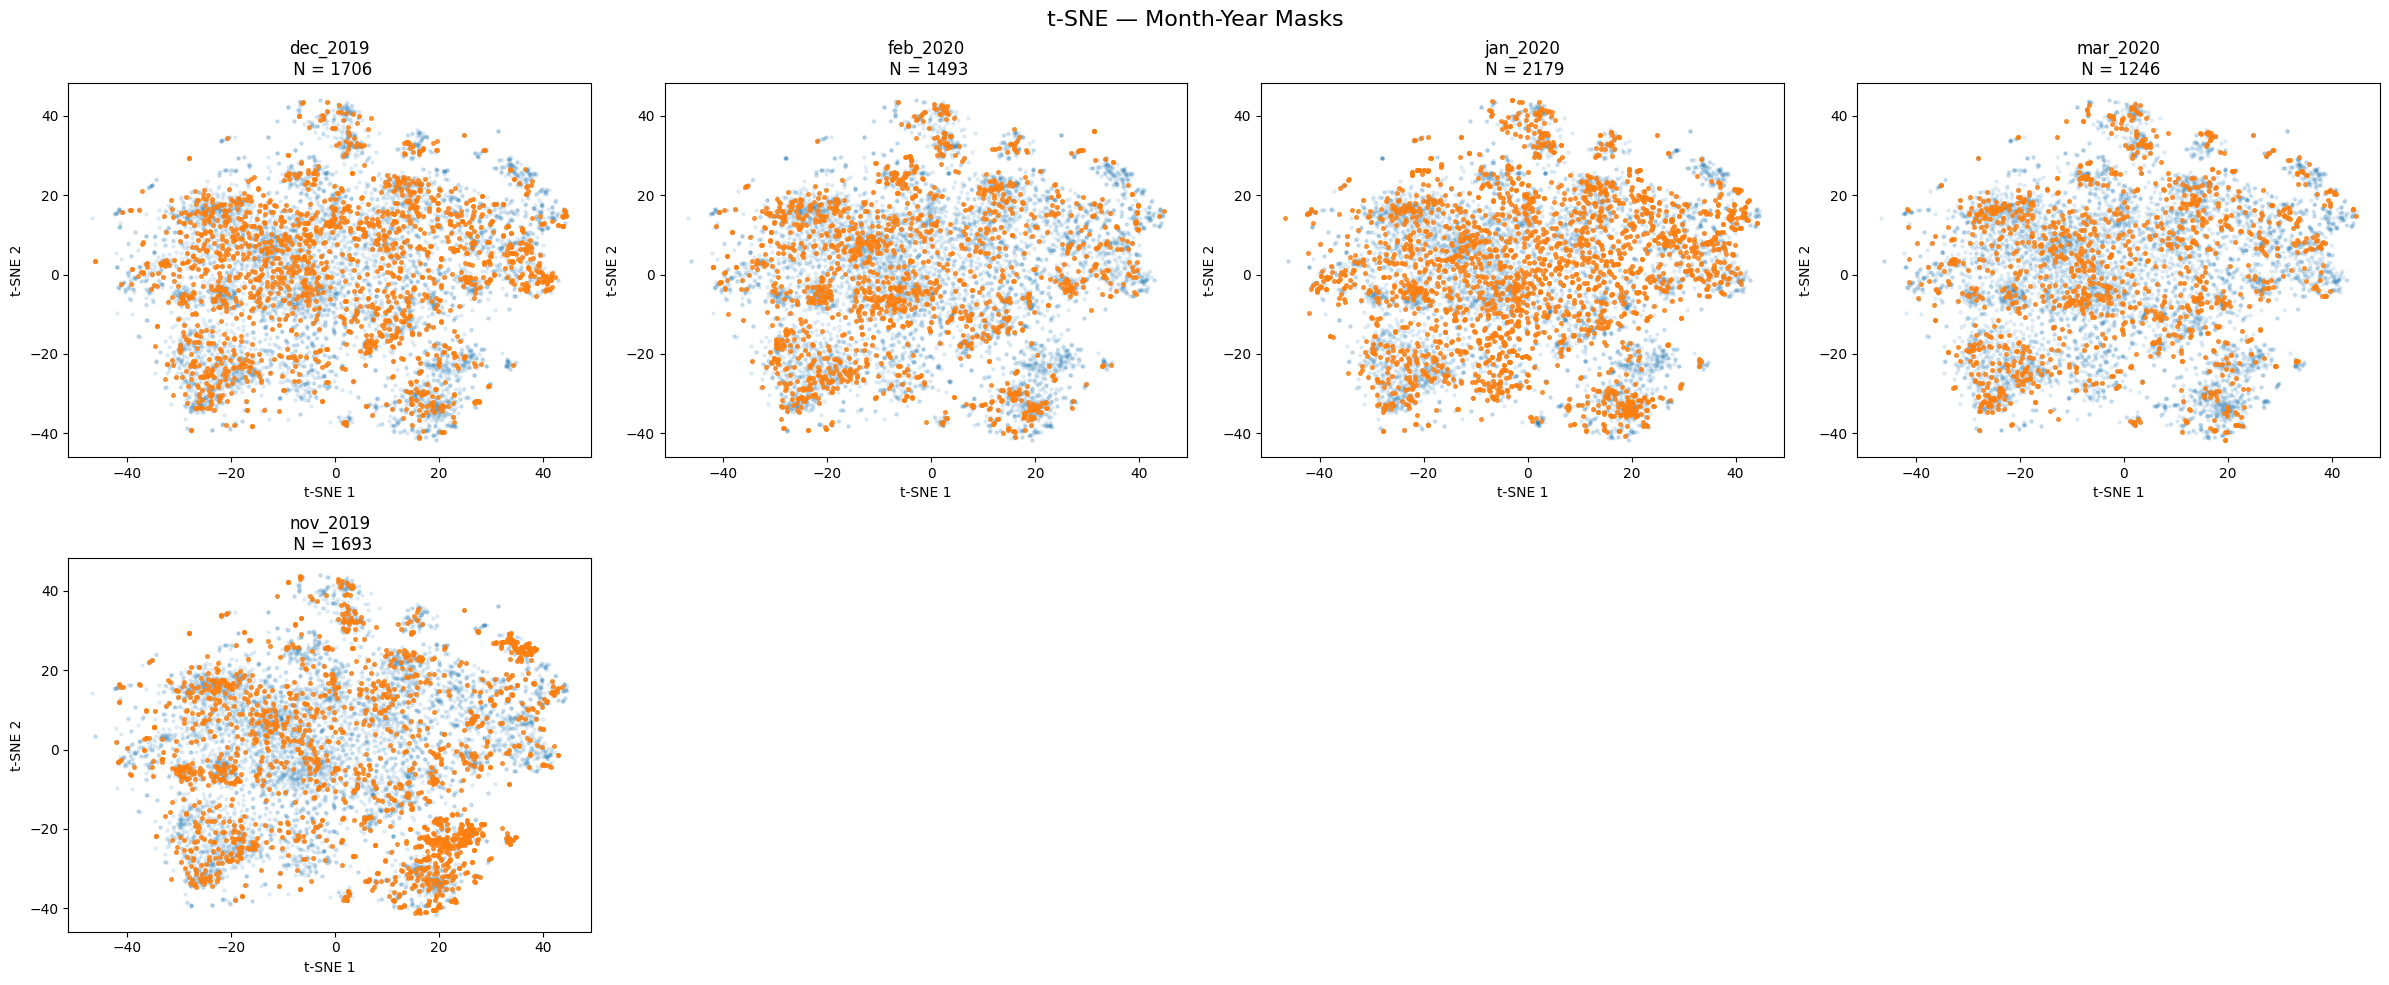

In [101]:
# Mask by month
month_year_values = sorted(df["month_year"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="month_year",values=month_year_values,figure_title="t-SNE — Month-Year Masks",ncols=4)

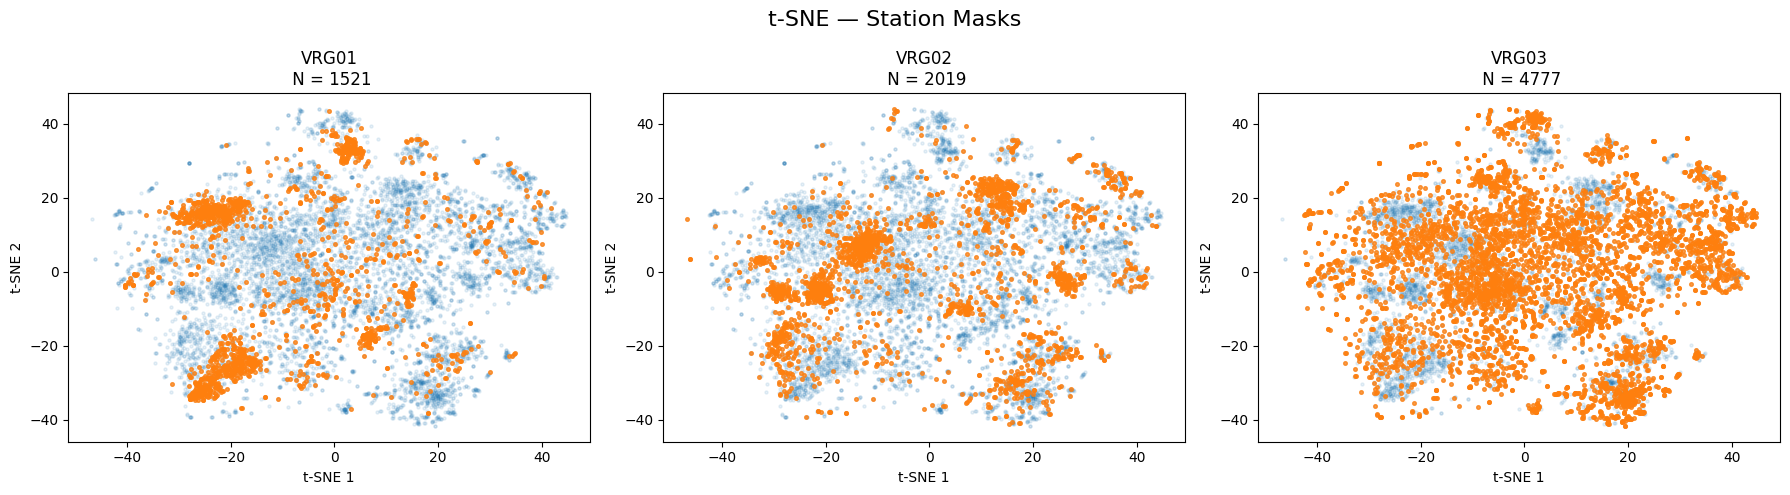

In [102]:
# Mask by station
station_values = sorted(df["station"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="station",values=station_values,figure_title="t-SNE — Station Masks",ncols=3)

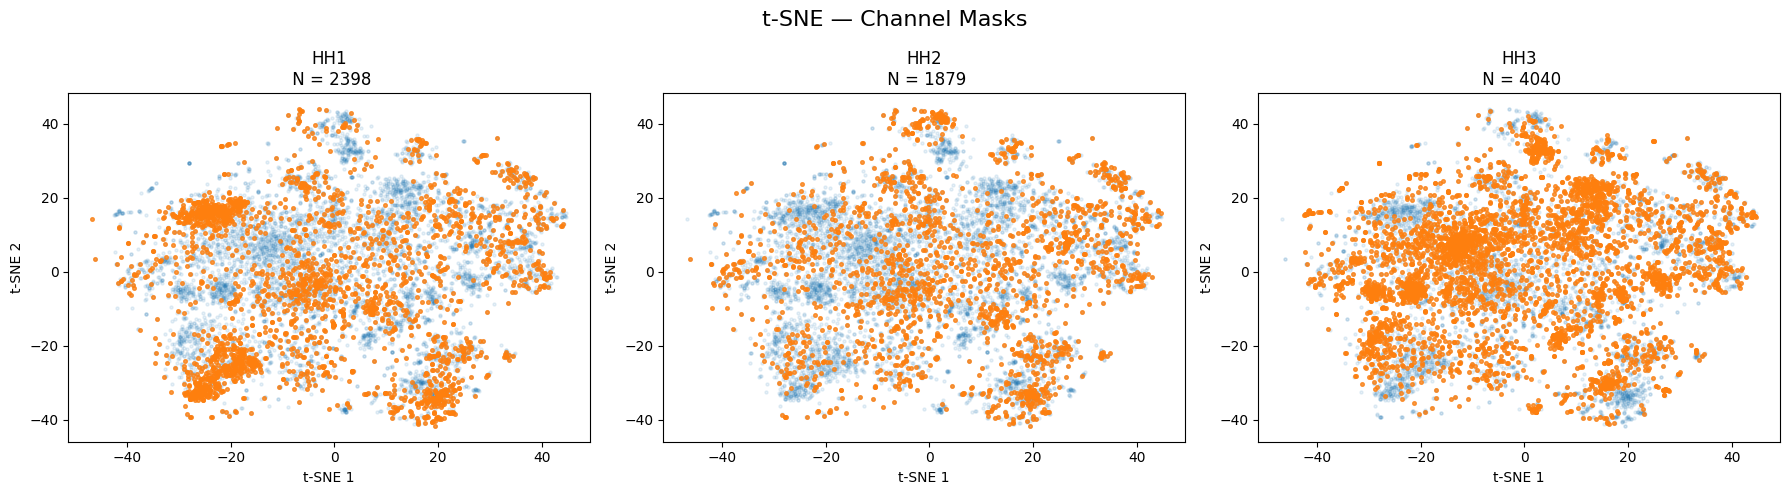

In [103]:
# Mask by channel
channel_values = sorted(df["channel"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="channel",values=channel_values,figure_title="t-SNE — Channel Masks",ncols=3)

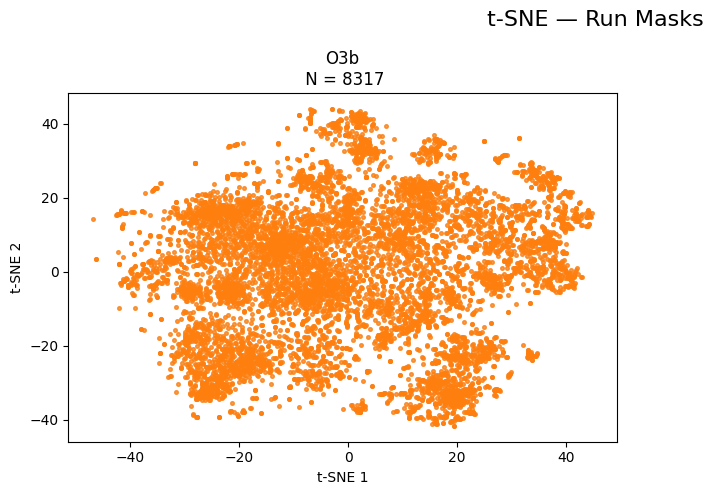

In [104]:
# Mask by run
run_values = sorted(df["run"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="run",values=run_values,figure_title="t-SNE — Run Masks",ncols=2)